In [ ]:
import pandas as pd
df=pd.read_csv('/content/ev_charging_station_usage_grid_load.csv')
df

,record_id,date_time,city_zone,station_type,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent,peak_load_risk
0,1,2024-01-01 00:00:00,Central,Supercharger,9,101.6,238.64,179.28,59.1,Medium
1,2,2024-01-01 01:00:00,South,Fast,15,23.5,129.50,198.56,73.6,Low
2,3,2024-01-01 02:00:00,West,Normal,3,104.7,65.67,134.21,63.7,Low
3,4,2024-01-01 03:00:00,West,Fast,22,108.6,303.83,76.49,17.0,Medium
4,5,2024-01-01 04:00:00,Central,Fast,21,78.6,156.32,256.73,17.9,Low
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-04-26 11:00:00,North,Fast,2,20.0,19.75,475.86,62.1,Low
2796,2797,2024-04-26 12:00:00,North,Normal,20,48.0,275.03,301.55,14.6,High
2797,2798,2024-04-26 13:00:00,East,Normal,12,35.2,77.45,193.15,14.9,Low
2798,2799,2024-04-26 14:00:00,South,Fast,5,16.5,348.38,153.71,10.8,Low


In [ ]:
df.shape

(2800, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   record_id                      2800 non-null   int64  
 1   date_time                      2800 non-null   object 
 2   city_zone                      2800 non-null   object 
 3   station_type                   2800 non-null   object 
 4   vehicles_charged               2800 non-null   int64  
 5   avg_charging_duration_minutes  2800 non-null   float64
 6   energy_dispensed_kwh           2800 non-null   float64
 7   grid_load_mw                   2800 non-null   float64
 8   renewable_energy_used_percent  2800 non-null   float64
 9   peak_load_risk                 2800 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 218.9+ KB


In [ ]:
df.isnull().sum()

,0
record_id,0
date_time,0
city_zone,0
station_type,0
vehicles_charged,0
avg_charging_duration_minutes,0
energy_dispensed_kwh,0
grid_load_mw,0
renewable_energy_used_percent,0
peak_load_risk,0


In [ ]:
df['city_zone'].unique()

array(['Central', 'South', 'West', 'North', 'East'], dtype=object)

In [ ]:
df['station_type'].unique()

array(['Supercharger', 'Fast', 'Normal'], dtype=object)

In [ ]:
df['peak_load_risk'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [ ]:
# Target
y = df['grid_load_mw']

In [ ]:
# Features
X = df.drop(columns=['grid_load_mw', 'record_id'])

In [ ]:
X = pd.get_dummies(X, columns=['city_zone', 'station_type', 'peak_load_risk'], drop_first=True)

In [ ]:
X.head()

,date_time,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,renewable_energy_used_percent,city_zone_East,city_zone_North,city_zone_South,city_zone_West,station_type_Normal,station_type_Supercharger,peak_load_risk_Low,peak_load_risk_Medium
0,2024-01-01 00:00:00,9,101.6,238.64,59.1,False,False,False,False,False,True,False,True
1,2024-01-01 01:00:00,15,23.5,129.50,73.6,False,False,True,False,False,False,True,False
2,2024-01-01 02:00:00,3,104.7,65.67,63.7,False,False,False,True,True,False,True,False
3,2024-01-01 03:00:00,22,108.6,303.83,17.0,False,False,False,True,False,False,False,True
4,2024-01-01 04:00:00,21,78.6,156.32,17.9,False,False,False,False,False,False,True,False


In [ ]:
# Date-time process
X['date_time'] = pd.to_datetime(X['date_time'])

X['hour'] = X['date_time'].dt.hour
X['day'] = X['date_time'].dt.day
X['month'] = X['date_time'].dt.month
X['day_of_week'] = X['date_time'].dt.dayofweek

In [ ]:
X = X.drop(columns=['date_time'])

In [ ]:
X = X.drop(columns=['peak_load_risk_High', 'peak_load_risk_Low'],errors='ignore')

In [ ]:
X.head()

,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,renewable_energy_used_percent,city_zone_East,city_zone_North,city_zone_South,city_zone_West,station_type_Normal,station_type_Supercharger,peak_load_risk_Medium,hour,day,month,day_of_week
0,9,101.6,238.64,59.1,False,False,False,False,False,True,True,0,1,1,0
1,15,23.5,129.50,73.6,False,False,True,False,False,False,False,1,1,1,0
2,3,104.7,65.67,63.7,False,False,False,True,True,False,False,2,1,1,0
3,22,108.6,303.83,17.0,False,False,False,True,False,False,True,3,1,1,0
4,21,78.6,156.32,17.9,False,False,False,False,False,False,False,4,1,1,0


In [ ]:
# Train & Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42
)


In [ ]:
# Linear Regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 116.28789829125992
RMSE: 132.98156897505186
R2 Score: -0.011328377260176659


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 116.58006241071428
RMSE: 134.8994480228003
R2 Score: -0.04070977429191425


In [ ]:
df.corr(numeric_only=True)['grid_load_mw'].sort_values(ascending=False)

,grid_load_mw
grid_load_mw,1.000000
avg_charging_duration_minutes,0.025139
vehicles_charged,0.007541
energy_dispensed_kwh,-0.003357
record_id,-0.009582
renewable_energy_used_percent,-0.025433


In [ ]:
df['grid_load_mw'].describe()

,grid_load_mw
count,2800.000000
mean,276.363725
std,130.040201
min,50.010000
25%,165.087500
50%,277.755000
75%,391.145000
max,499.970000


In [ ]:
df.groupby('peak_load_risk')['grid_load_mw'].mean()

,grid_load_mw
peak_load_risk,
High,275.546855
Low,275.403283
Medium,278.545422


In [ ]:
df.corr(numeric_only=True)['grid_load_mw'].sort_values(ascending=False)

,grid_load_mw
grid_load_mw,1.000000
avg_charging_duration_minutes,0.025139
vehicles_charged,0.007541
energy_dispensed_kwh,-0.003357
record_id,-0.009582
renewable_energy_used_percent,-0.025433


In [ ]:
df.columns

Index(['record_id', 'date_time', 'city_zone', 'station_type',
       'vehicles_charged', 'avg_charging_duration_minutes',
       'energy_dispensed_kwh', 'grid_load_mw', 'renewable_energy_used_percent',
       'peak_load_risk'],
      dtype='object')

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek

In [ ]:
df.corr(numeric_only=True)['grid_load_mw'].sort_values(ascending=False)

,grid_load_mw
grid_load_mw,1.000000
avg_charging_duration_minutes,0.025139
day_of_week,0.024378
day,0.018237
vehicles_charged,0.007541
energy_dispensed_kwh,-0.003357
record_id,-0.009582
month,-0.013794
hour,-0.015439
renewable_energy_used_percent,-0.025433


In [ ]:
X = df.drop(columns=['grid_load_mw', 'record_id', 'date_time'])
y = df['grid_load_mw']

In [ ]:
X = pd.get_dummies(X,columns=['city_zone', 'station_type', 'peak_load_risk'],drop_first=True
)

In [ ]:
X.head()

,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,renewable_energy_used_percent,hour,day,month,day_of_week,city_zone_East,city_zone_North,city_zone_South,city_zone_West,station_type_Normal,station_type_Supercharger,peak_load_risk_Low,peak_load_risk_Medium
0,9,101.6,238.64,59.1,0,1,1,0,False,False,False,False,False,True,False,True
1,15,23.5,129.50,73.6,1,1,1,0,False,False,True,False,False,False,True,False
2,3,104.7,65.67,63.7,2,1,1,0,False,False,False,True,True,False,True,False
3,22,108.6,303.83,17.0,3,1,1,0,False,False,False,True,False,False,False,True
4,21,78.6,156.32,17.9,4,1,1,0,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2240, 16)
(560, 16)
(2240,)
(560,)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 116.29341357873795
RMSE: 132.99373740359502
R2 Score: -0.01151346817507326


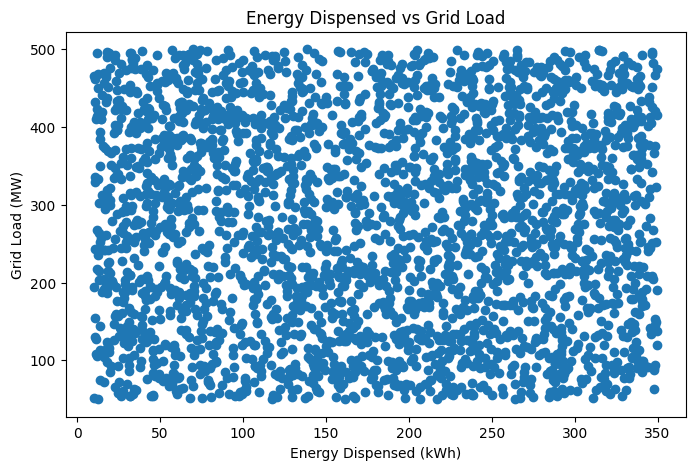

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['energy_dispensed_kwh'], df['grid_load_mw'])
plt.xlabel('Energy Dispensed (kWh)')
plt.ylabel('Grid Load (MW)')
plt.title('Energy Dispensed vs Grid Load')
plt.show()

In [ ]:
df['load_category'] = pd.qcut(
    df['grid_load_mw'],
    3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df[['grid_load_mw', 'load_category']].head()

,grid_load_mw,load_category
0,179.28,Low
1,198.56,Low
2,134.21,Low
3,76.49,Low
4,256.73,Medium


In [ ]:
X = df.drop(columns=['grid_load_mw', 'load_category', 'record_id', 'date_time'])
y = df['load_category']

In [ ]:
X = pd.get_dummies(
    X,
    columns=['city_zone', 'station_type', 'peak_load_risk'],
    drop_first=True
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.32857142857142857


In [ ]:
print(X.columns)

Index(['vehicles_charged', 'avg_charging_duration_minutes',
       'energy_dispensed_kwh', 'renewable_energy_used_percent', 'hour', 'day',
       'month', 'day_of_week', 'city_zone_East', 'city_zone_North',
       'city_zone_South', 'city_zone_West', 'station_type_Normal',
       'station_type_Supercharger', 'peak_load_risk_Low',
       'peak_load_risk_Medium'],
      dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.3375


In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_clf.predict(X_test)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.34285714285714286
